# 01 EDA: Data loading and label sanity checks

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

In [2]:
from src.data.loading import build_labeled_dataset

DATA_DIR = PROJECT_ROOT / "data"
LABELS_PATH = DATA_DIR / "combined_windows.json"

SERIES_FILES = [
    DATA_DIR / "realAWSCloudwatch/ec2_cpu_utilization_fe7f93.csv",
    DATA_DIR / "realAWSCloudwatch/rds_cpu_utilization_e47b3b.csv",
    DATA_DIR / "realAWSCloudwatch/grok_asg_anomaly.csv",
]

dataset_df = build_labeled_dataset(
    series_paths=SERIES_FILES,
    labels_path=LABELS_PATH,
)

dataset_df.head()

,timestamp,value,series_id,is_incident
0,2014-02-14 14:27:00,2.296,realAWSCloudwatch/ec2_cpu_utilization_fe7f93.csv,0
1,2014-02-14 14:32:00,2.144,realAWSCloudwatch/ec2_cpu_utilization_fe7f93.csv,0
2,2014-02-14 14:37:00,2.274,realAWSCloudwatch/ec2_cpu_utilization_fe7f93.csv,0
3,2014-02-14 14:42:00,2.066,realAWSCloudwatch/ec2_cpu_utilization_fe7f93.csv,0
4,2014-02-14 14:47:00,2.350,realAWSCloudwatch/ec2_cpu_utilization_fe7f93.csv,0


In [3]:
from src.data.loading import summarize_series

summary_df = summarize_series(dataset_df)
summary_df

,series_id,rows,first_timestamp,last_timestamp,incident_points,min_value,max_value
0,realAWSCloudwatch/ec2_cpu_utilization_fe7f93.csv,4032,2014-02-14 14:27:00,2014-02-28 14:22:00,405,1.800,99.6680
1,realAWSCloudwatch/grok_asg_anomaly.csv,4621,2014-01-16 00:00:00,2014-02-01 01:00:00,465,0.000,45.6229
2,realAWSCloudwatch/rds_cpu_utilization_e47b3b.csv,4032,2014-04-10 00:02:00,2014-04-23 23:57:00,402,12.628,76.2300


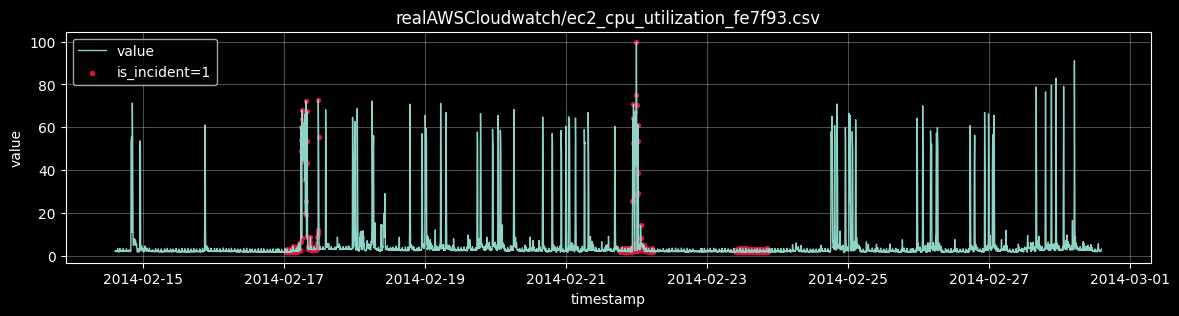

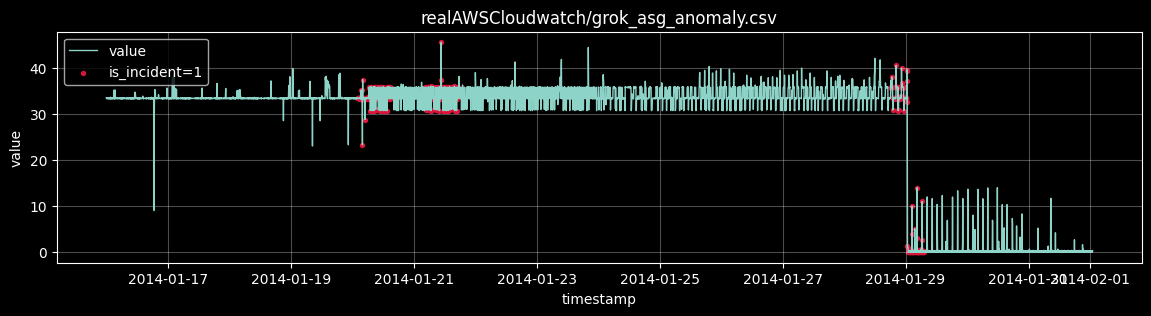

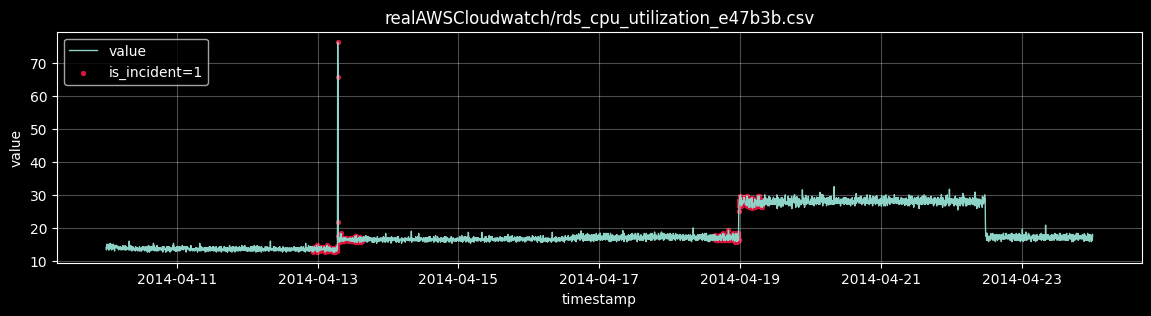

In [4]:
for series_id, series_df in dataset_df.groupby("series_id", sort=False):
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(series_df["timestamp"], series_df["value"], label="value", linewidth=1)

    incident_df = series_df[series_df["is_incident"] == 1]
    ax.scatter(
        incident_df["timestamp"],
        incident_df["value"],
        s=8,
        c="crimson",
        label="is_incident=1",
    )

    ax.set_title(series_id)
    ax.set_xlabel("timestamp")
    ax.set_ylabel("value")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
    plt.show()

In [5]:
dataset_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12685 entries, 0 to 12684
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   timestamp    12685 non-null  datetime64[us]
 1   value        12685 non-null  float64       
 2   series_id    12685 non-null  str           
 3   is_incident  12685 non-null  int64         
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 396.5 KB


In [5]:
from src.data.windowing import make_sliding_windows
from src.data.loading import normalize_series

WINDOW_SIZE = 24
HORIZON = 12

dataset_df = normalize_series(dataset_df)

training_df = make_sliding_windows(
    dataset=dataset_df,
    window_size=WINDOW_SIZE,
    horizon=HORIZON,
)

print(f"training_df shape: {training_df[0].shape}")
print(f"positive class ratio: {training_df[1].mean():.4f}")

training_df shape: (11124, 1, 24)
positive class ratio: 0.0086


## Analyzing random splits that will be used in the experiments

In [7]:
from src.data.datasets import load_features_dataset, load_timeseries_dataset
import pandas as pd

### Featured dataset approach

#### Random Forest

In [8]:
data = load_features_dataset(12, 36)
X_train_f, y_train_f = data["X_train"], data["y_train"]
X_val_f, y_val_f = data["X_val"], data["y_val"]
X_test_f, y_test_f = data["X_test"], data["y_test"]

Positive class ratio

In [9]:
print(f"Training set: {X_train_f.shape}, positive ratio: {y_train_f.mean():.4f}")
print(f"Validation set: {X_val_f.shape}, positive ratio: {y_val_f.mean():.4f}")
print(f"Test set: {X_test_f.shape}, positive ratio: {y_test_f.mean():.4f}")

Training set: (38412, 10), positive ratio: 0.0159
Validation set: (10703, 10), positive ratio: 0.0135
Test set: (11184, 10), positive ratio: 0.0258


In [13]:
pd.DataFrame(X_train_f).describe()

,0,1,2,3,4,5,6,7,8,9
count,38412.000000,38412.000000,38412.000000,38412.000000,38412.000000,38412.000000,38412.000000,38412.000000,38412.000000,38412.000000
mean,-0.028469,0.387211,-0.407701,0.903592,0.000611,0.314876,-0.331701,1.162621,-0.121584,0.254027
std,0.528252,0.623094,0.524381,2.219286,1.068906,0.829981,0.488479,4.342215,0.498019,0.379579
min,-5.329096,0.000000,-5.467080,-4.465483,-18.025720,-5.362847,-5.438418,0.000000,-5.415833,0.000000
25%,-0.217466,0.037587,-0.636022,-0.162968,-0.059138,-0.162968,-0.618314,0.002793,-0.245840,0.004151
50%,-0.108926,0.167789,-0.245840,0.178619,0.000000,0.081180,-0.245840,0.048295,-0.162968,0.115342
75%,0.058295,0.390808,-0.162968,1.029441,0.055304,0.552174,-0.162968,0.391931,0.024814,0.280760
max,6.904758,4.965626,4.083606,17.779880,18.025720,11.216009,4.413133,59.302574,7.602343,7.910137


Feature 9 has a shift of 0.71 std which is considerable, but the rest looks healthy that's why I decided to move to modeling either way

In [11]:
print(f"Standardized shift:\n{((X_val_f.mean(axis=0) - X_train_f.mean(axis=0)) / X_train_f.std(axis=0))}")

Standardized shift:
[ 0.00785094  0.09875067 -0.11544187  0.00145797 -0.00113835  0.28686603
 -0.19488578 -0.12261215 -0.06694994  0.73531613]


Train a Baseline RF

In [12]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42, class_weight="balanced_subsample")
model.fit(X_train_f, y_train_f)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [13]:
from sklearn.metrics import average_precision_score

train_ap = average_precision_score(y_train_f, model.predict_proba(X_train_f)[:,1])
val_ap = average_precision_score(y_val_f, model.predict_proba(X_val_f)[:,1])

print("Train AP:", train_ap)
print("Val AP:", val_ap)
print("Gap:", train_ap - val_ap)

Train AP: 0.8170925215062609
Val AP: 0.013108937646273492
Gap: 0.8039835838599874


In [14]:
from src.data.loading import load_incident_windows
from src.evaluate import pick_threshold

y_probs = model.predict_proba(X_val_f)[:, 1]
result = pick_threshold(
    meta_val=data["meta_val"],
    probs_val=y_probs,
    incident_windows_by_series=load_incident_windows(LABELS_PATH),
    horizon_steps=36,
)

print(result)

{'threshold': 0.02, 'incident_recall': 1.0, 'incidents_total': 4, 'incidents_caught': 4, 'lead_time_median_min': np.float64(172.5), 'false_alerts_per_day': 93.36766427018891}


In [15]:
from src.evaluate import alerting_eval

thresholds = [0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20]

rows = []
for thr in thresholds:
    m = alerting_eval(
        meta_df=data["meta_val"],
        y_probs=y_probs,
        incident_windows_by_series=load_incident_windows(LABELS_PATH),
        threshold=thr,
        horizon_steps=36,
    )
    rows.append(m)

df = pd.DataFrame(rows)
df

,threshold,incident_recall,incidents_total,incidents_caught,lead_time_median_min,false_alerts_per_day
0,0.01,1.00,4,4,180.0,157.627153
1,0.02,1.00,4,4,172.5,93.367664
2,0.03,0.75,4,3,175.0,59.877612
3,0.05,0.75,4,3,135.0,30.552750
4,0.08,0.00,4,0,NaN,14.590202
5,0.10,0.00,4,0,NaN,8.715599
6,0.15,0.00,4,0,NaN,1.974252
7,0.20,0.00,4,0,NaN,1.131583


In [16]:
y_probs = model.predict_proba(X_val_f)[:,1]

y_pred = (y_probs >= 0.01).astype(int)
print("predicted positives:", y_pred.sum(), "out of", len(y_pred))
print("true positives:", ((y_pred == 1) & (y_val_f == 1)).sum())
print("actual positives in val set:", y_val_f.sum())

predicted positives: 6655 out of 10703
true positives: 108
actual positives in val set: 144


The tree overfitted extremely. The signal exists but is very weak and unstable. Probably because I am doing cross-series generalization which is much more difficult than normal classification

In [17]:
model.feature_importances_

array([0.10684848, 0.11826117, 0.09225583, 0.14234578, 0.04057605,
       0.12904517, 0.08937078, 0.10281878, 0.09271979, 0.08575817])

In [18]:
len(model.estimators_)

100

#### XGBoost

In [19]:
from xgboost import XGBClassifier

model = XGBClassifier(random_state=42)
model.fit(X_train_f, y_train_f)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [20]:
train_ap = average_precision_score(y_train_f, model.predict_proba(X_train_f)[:,1])
val_ap = average_precision_score(y_val_f, model.predict_proba(X_val_f)[:,1])

print("Train AP:", train_ap)
print("Val AP:", val_ap)
print("Gap:", train_ap - val_ap)

Train AP: 0.8364522548366812
Val AP: 0.008776273822528165
Gap: 0.827675981014153


We can also observe massive overfitting to the data, and no

In [21]:
y_probs = model.predict_proba(X_val_f)[:, 1]
result = pick_threshold(
    meta_val=data["meta_val"],
    probs_val=y_probs,
    incident_windows_by_series=load_incident_windows(LABELS_PATH),
    horizon_steps=36,
)

print(result)

{'threshold': 0.01, 'incident_recall': 0.25, 'incidents_total': 4, 'incidents_caught': 1, 'lead_time_median_min': np.float64(140.0), 'false_alerts_per_day': 41.9408125731483}


### Timeseries dataset approach

In [14]:
data = load_timeseries_dataset(144, 3)
X_train_t, y_train_t = data["X_train"], data["y_train"]
X_val_t, y_val_t = data["X_val"], data["y_val"]
X_test_t, y_test_t = data["X_test"], data["y_test"]

Positive class ratio

In [15]:
print(f"Training set: {X_train_t.shape}, positive ratio: {y_train_t.mean():.4f}")
print(f"Validation set: {X_val_t.shape}, positive ratio: {y_val_t.mean():.4f}")
print(f"Test set: {X_test_t.shape}, positive ratio: {y_test_t.mean():.4f}")

Training set: (35177, 1, 144), positive ratio: 0.0014
Validation set: (9878, 1, 144), positive ratio: 0.0012
Test set: (9831, 1, 144), positive ratio: 0.0024


In [24]:
pd.DataFrame(X_train_t.squeeze(1)).describe()

,0,1,2,3,4,5,6,7,8,9,...,134,135,136,137,138,139,140,141,142,143
count,35177.000000,35177.000000,35177.000000,35177.000000,35177.000000,35177.000000,35177.000000,35177.000000,35177.000000,35177.000000,...,35177.000000,35177.000000,35177.000000,35177.000000,35177.000000,35177.000000,35177.000000,35177.000000,35177.000000,35177.000000
mean,-0.048472,-0.048362,-0.048394,-0.048749,-0.048706,-0.048547,-0.048483,-0.048419,-0.048430,-0.048255,...,-0.043634,-0.043720,-0.043560,-0.043434,-0.043438,-0.043411,-0.043392,-0.043503,-0.043334,-0.043180
std,0.883140,0.882633,0.880561,0.877553,0.875724,0.874360,0.873510,0.872845,0.872232,0.872503,...,0.880486,0.880446,0.880530,0.880565,0.880441,0.880429,0.880438,0.880280,0.880292,0.880347
min,-5.467080,-5.467080,-5.467080,-5.467080,-5.467080,-5.467080,-5.467080,-5.467080,-5.467080,-5.467080,...,-1.966875,-1.966875,-1.966875,-1.966875,-1.966875,-1.966875,-1.966875,-1.966875,-1.966875,-1.966875
25%,-0.291304,-0.291304,-0.291304,-0.291304,-0.291304,-0.291304,-0.291304,-0.291304,-0.291304,-0.291304,...,-0.291304,-0.291304,-0.291304,-0.291304,-0.291304,-0.291304,-0.291304,-0.291304,-0.291304,-0.291304
50%,-0.162968,-0.162968,-0.162968,-0.162968,-0.162968,-0.162968,-0.162968,-0.162968,-0.162968,-0.162968,...,-0.162968,-0.162968,-0.162968,-0.162968,-0.162968,-0.162968,-0.162968,-0.162968,-0.162968,-0.162968
75%,0.060086,0.060086,0.060086,0.060086,0.060086,0.060086,0.060086,0.060086,0.060086,0.060086,...,0.062154,0.062154,0.062173,0.062265,0.062188,0.062389,0.062389,0.062319,0.062485,0.062733
max,17.779880,17.779880,17.779880,17.779880,17.779880,17.779880,17.779880,17.779880,17.779880,17.779880,...,17.779880,17.779880,17.779880,17.779880,17.779880,17.779880,17.779880,17.779880,17.779880,17.779880


In [27]:
WINDOW_SIZE = 144
HORIZON = 12

# True ratio ≈ 188, but start with 100 for stability in a quick sanity run.
POS_WEIGHT = 100

config = {
    "model_name": "InceptionTimePlus",
    "window_size": WINDOW_SIZE,
    "horizon": HORIZON,

    # Sanity-check values (reasonable defaults)
    "batch_size": 256,
    "learning_rate": 1e-3,
    "epochs": 30,
    "patience": 4,
    "pos_weight": POS_WEIGHT,

    # InceptionTimePlus tends to be stable with these
    "model_kwargs": {
        "nf": 32,      # number of filters
        "depth": 6,    # number of inception blocks
        "ks": 40,      # kernel size (works well for W=144)
    },
}

In [28]:
import importlib
import src.train as train
importlib.reload(train)

import os
os.environ["OMP_NUM_THREADS"] = "1"

from src.train import train_deep_classifier
import wandb
import fastai

fastai.torch_core.defaults.silent = True

wandb.init(
    entity="tombik-warsaw-university-of-technology",
    project="Predictive-alerting-for-cloud-metrics",
    config=config,
)

model = train_deep_classifier(X_train_t, y_train_t, X_val_t, y_val_t, config)

wandb.finish()


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/tomek/.netrc.
wandb: Currently logged in as: tombik (tombik-warsaw-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run xbgt12kg
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /Users/tomek/Developer/Predictive-alerting-for-cloud-metrics/notebooks/wandb/run-20260222_143815-xbgt12kg
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run fearless-aardvark-28
wandb: ⭐️ View project at https://wandb.ai/tombik-warsaw-university-of-technology/Predictive-alerting-for-cloud-metrics
wandb: 🚀 View run at https://wandb.ai/tombik-warsaw-university-of-technology/Predictive-alerting-for-cloud-metrics/runs/xbgt12kg


epoch,train_loss,valid_loss,average_precision_score,time
0,0.375360,0.341537,0.001011,00:25
1,0.296541,0.258341,0.000864,00:24
2,0.278305,0.238592,0.001089,00:24
3,0.277724,0.236487,0.001781,00:24
4,0.333559,0.289015,0.001058,00:24
5,0.257126,0.226613,0.001035,00:24
6,0.304619,0.262537,0.001575,00:24
7,0.298972,0.265239,0.001351,00:25
8,0.277227,0.304119,0.000944,00:24
9,0.265002,0.261899,0.001153,00:24


Better model found at epoch 0 with valid_loss value: 0.3415365219116211.
Better model found at epoch 1 with valid_loss value: 0.25834110379219055.
Better model found at epoch 2 with valid_loss value: 0.2385924756526947.
Better model found at epoch 3 with valid_loss value: 0.236486554145813.
Better model found at epoch 5 with valid_loss value: 0.22661270201206207.
No improvement since epoch 5: early stopping


wandb: updating run metadata
wandb: uploading output.log; uploading wandb-summary.json; uploading config.yaml
wandb: uploading wandb-summary.json
wandb: uploading history steps 1328-1369, summary, console lines 5-5
wandb: 
wandb: Run history:
wandb: average_precision_score ▂▁▃█▂▂▆▅▂▃
wandb:                   epoch ▁▁▁▁▂▂▂▂▂▂▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇██
wandb:                   eps_0 ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:                   eps_1 ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:                    lr_0 ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:                    lr_1 ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:                   mom_0 ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:                   mom_1 ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:                raw_loss █▁▁▂▅▁▅▅▁▅▆▁▄▂▁▁▆▁▁▁▂▅▂▂▁▁█▁▆▁▁▁▁█▁▄▁▁▄▅
wandb:               sqr_mom_0 ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:                      +6 ...
wandb: 
wandb: Run summary:
wand

In [36]:
import importlib
import src.data.datasets as datasets
import src.evaluate as evaluate
importlib.reload(datasets)
importlib.reload(evaluate)

from src.data.datasets import load_timeseries_dataset

data = load_timeseries_dataset(144, 3)
X_train_t, y_train_t = data["X_train"], data["y_train"]
X_val_t, y_val_t = data["X_val"], data["y_val"]
X_test_t, y_test_t = data["X_test"], data["y_test"]

In [37]:
from src.data.loading import load_incident_windows
from src.evaluate import pick_threshold, predict_proba_tsai

y_probs = predict_proba_tsai(model, X_val_t)
result = pick_threshold(
    meta_val=data["meta_val"],
    probs_val=y_probs,
    incident_windows_by_series=load_incident_windows(LABELS_PATH),
    horizon_steps=3,
)

print(result)

{'threshold': 0.02, 'incident_recall': 1.0, 'incidents_total': 4, 'incidents_caught': 4, 'lead_time_median_min': np.float64(15.0), 'false_alerts_per_day': 178.55851839149446}
